# Fashion-MNISTを使ってみる
10/24(月)〜10/31(金)の研究室宿題

### Fashion-MNISTとは？

ファッション商品（写真）の画像データセット。  
7万枚の写真（ファッション商品）の「画像＋ラベル」データが無料でダウンロードでき、画像認識などのディープラーニングに利用できる。  
https://atmarkit.itmedia.co.jp/ait/articles/2005/28/news016.html

### 実践（訓練データ＆テストデータを見てみよう）

In [27]:
# 各種import

# データセット
from tensorflow.keras import datasets

# グラフ描画
import matplotlib.pyplot as plt

# 数値計算
import numpy as np


In [28]:
# Fashion-MNIST読み込み
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

In [29]:
# データ形式の確認
print("x_train shape:",x_train.shape)
print("y_train shape:",y_train.shape)
print("---------------------------------")
print("x_test shape:",x_test.shape)
print("y_test shape:",y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
---------------------------------
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


##### .shapeって？  
各次元の要素数のこと。  
ｘは2次元で 28 * 28 の画像であり、ｙはラベルなので1次元かつ要素数1で出てこない。多分。

In [30]:
# 各クラスの確認
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
labels = np.arange(len(class_names))
for label,class_name in zip(labels,class_names):
    print(label,":",class_name)

0 : T-shirt/top
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle boot


##### .arrangeって？  
スタート位置や長さを指定すれば、等間隔で番号を振ってくれるもの。リストとして収納される。  
https://note.nkmk.me/python-numpy-arange-linspace/

##### zipって？  
for文の中で複数のイテラブルオブジェクトを同時に取得したいときに使うもの。一つだけ取得の時はいらない。  
https://note.nkmk.me/python-zip-usage-for/

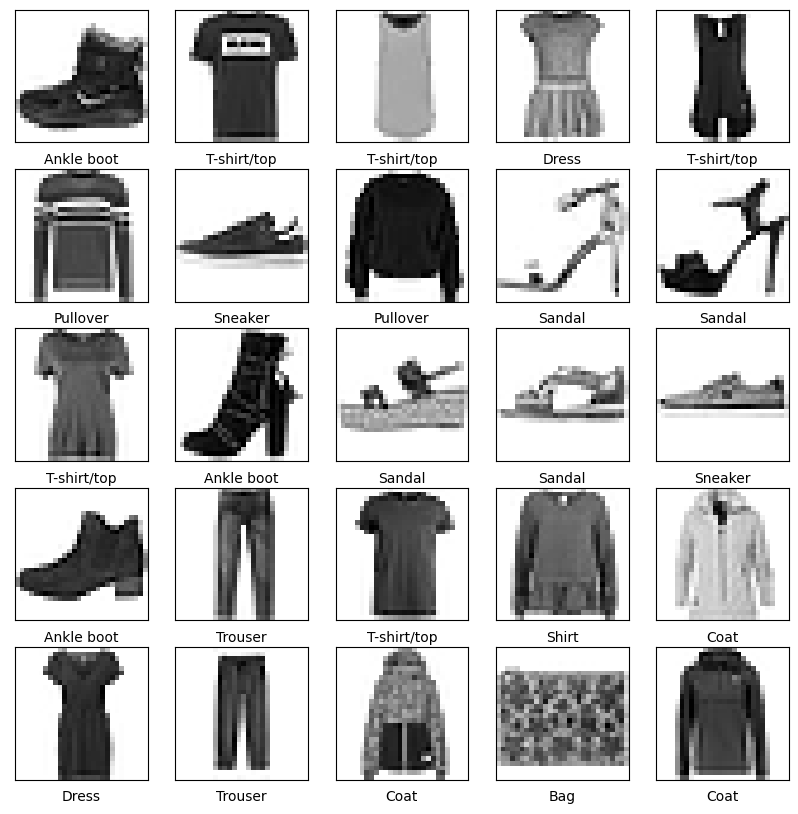

In [31]:
# 画像を試しに見てみる(訓練データ上から25個)
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

##### .subplotって？  
画像やグラフを1枚にまとめるもの。subplot(列, 行, 挿入する位置)。  
https://stats.biopapyrus.jp/python/subplot.html

##### .xticks .yticksって？　　
X軸、Y軸に目盛りを付けるもの。何も指定しなかったら、ただの四角形が表示される。  
http://www2.yukawa.kyoto-u.ac.jp/~koudai.sugimoto/dokuwiki/doku.php?id=python:matplotlib:%E7%9B%AE%E7%9B%9B%E3%82%8A%E3%81%AE%E8%A8%AD%E5%AE%9A

##### .gridって？  
グリッドの表示設定。FalseなのでOFF。  
https://tech-market.org/matplotlib-grid/

##### .imshowって？  
多分 image show の略。画像を表示するもの。.imshow(画像, カラーマップ)。  
カラーマップはざっくり言うとカラー表示するか、モノクロ表示するか見たいな話。  
http://taustation.com/pyplot-imshow/  
https://beiznotes.org/matplot-cmap-list/

##### .xlabelって？  
X軸方向のラベルをつける。今回は画像のタイトルとして使われている。  
https://pystyle.info/matplotlib-set-xy-label-and-title/

### 実践（テストデータを使って識別してみよう）

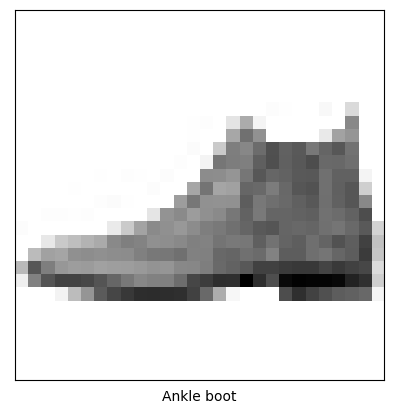

y_test : 9


In [32]:
# 試しにテストデータを見てみる（1番目を表示）
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.imshow(x_test[0], cmap=plt.cm.binary)
plt.xlabel(class_names[y_test[0]])

plt.show()
print(f'y_test : {y_test[0]}')

1番目のテストデータを予測させて、「9」が返ってきたら成功！

##### ーーーーーーーーー機械学習スタートーーーーーーーーー

##### 1、学習の準備

In [33]:
# 各種import

from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras
 
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.10.0


In [34]:
# Fashion-Mnistの読み込み

fashion_mnist = keras.datasets.fashion_mnist
 
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [35]:
# ラベル（判別結果）の名前を設定しておく

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

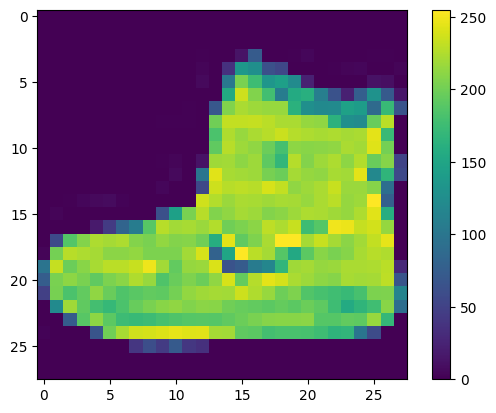

In [36]:
# 訓練データの確認

plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [37]:
# ニューラルネットワークモデルに合わせるために0〜1の範囲にスケールする（データの前処理）

train_images = train_images / 255.0
test_images = test_images / 255.0

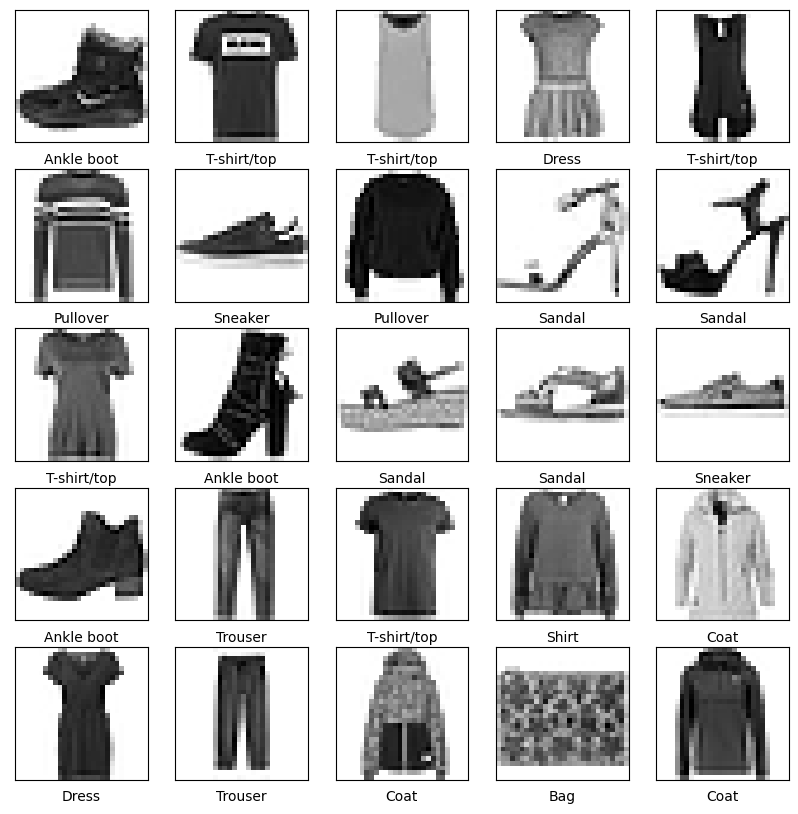

In [38]:
# データの準備は完了→確認

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

##### 2、学習

In [39]:
# ニューラルネットワークの構築（モデルの層を構成して、それからモデルをコンパイルする）

# 層をセットアップする
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# モデルをコンパイルする
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [40]:
# モデルを訓練する

model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
   1/1875 [..............................] - ETA: 5:11 - loss: 2.3803 - accuracy: 0.1250

2022-11-07 12:37:06.244013: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


1875/1875 [==============================] - 1s 498us/step - loss: 0.4920 - accuracy: 0.8265
Epoch 2/10
1875/1875 [==============================] - 1s 491us/step - loss: 0.3710 - accuracy: 0.8651
Epoch 3/10
1875/1875 [==============================] - 1s 493us/step - loss: 0.3325 - accuracy: 0.8781
Epoch 4/10
1875/1875 [==============================] - 1s 489us/step - loss: 0.3100 - accuracy: 0.8850
Epoch 5/10
1875/1875 [==============================] - 1s 495us/step - loss: 0.2924 - accuracy: 0.8911
Epoch 6/10
1875/1875 [==============================] - 1s 492us/step - loss: 0.2795 - accuracy: 0.8965
Epoch 7/10
1875/1875 [==============================] - 1s 493us/step - loss: 0.2668 - accuracy: 0.9007
Epoch 8/10
1875/1875 [==============================] - 1s 491us/step - loss: 0.2551 - accuracy: 0.9042
Epoch 9/10
1875/1875 [==============================] - 1s 491us/step - loss: 0.2474 - accuracy: 0.9083
Epoch 10/10
1875/1875 [==============================] - 1s 493us/step - lo

In [41]:
# 精度を評価する

test_loss, test_acc = model.evaluate(test_images, test_labels)
 
print('\nTest accuracy:', test_acc)

313/313 [==============================] - 0s 341us/step - loss: 0.3490 - accuracy: 0.8731

Test accuracy: 0.8730999827384949


##### 3、予測

In [42]:
# テストデータの予測結果をまとめて変数「predictions」に格納

predictions = model.predict(test_images)

313/313 [==============================] - 0s 289us/step


In [43]:
# 1番目のテストデータの予測結果を試しに見てみる（各ラベルの確信度が出る）

predictions[0]

array([3.4980593e-07, 7.6588652e-10, 1.8170786e-08, 4.0883817e-11,
       1.1773725e-08, 2.1200006e-04, 1.4730969e-07, 1.3357270e-02,
       1.8130257e-07, 9.8642993e-01], dtype=float32)

In [44]:
# 最も確信度が高い → 予測の結論

np.argmax(predictions[0])

9

＜ここまでのおさらい＞  
機械学習を行い、1番目のテストデータの予測結果が「9」と出た。  
→ 1番目のテストデータの本当の結果（test_labels[0]）が「9」なら、予測成功！

In [45]:
# 1番目のテストデータの答え（ラベル）を確認
test_labels[0]

9

予測結果と実際の結果が一致したので、成功！

##### ーーーーーーーーー機械学習ゴールーーーーーーーーー

### 実践（ネット上の服を持ってきて予測させてみよう）

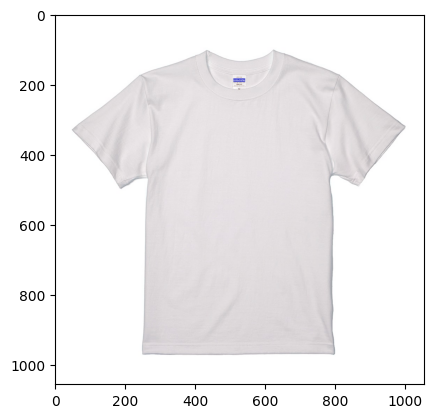

In [133]:
# 画像を変数に保存

import cv2

img = cv2.imread('/Users/matsumotokotarou/My_Data/Local_Programing/labo/fashion-mnist/T-shirt(1).jpg')
plt.imshow(img)

##### 1、画像を予測できるように加工

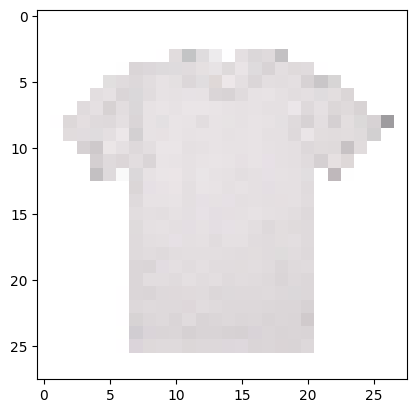

In [134]:
# 画像サイズを28x28に変更

img = cv2.resize(img, dsize=(28, 28))
plt.imshow(img)

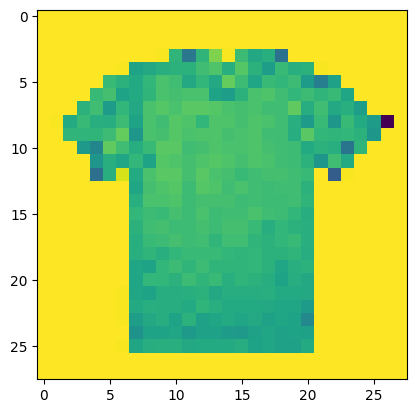

In [135]:
# グレースケール化

img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img)

In [136]:
# ニューラルネットワークモデルに合わせるために0〜1の範囲にスケールする（データの前処理）

img = img / 255.0

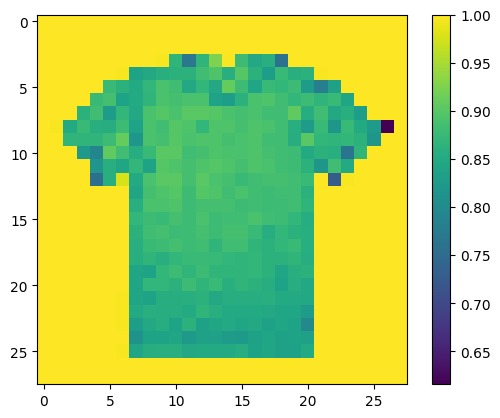

In [137]:
# 画像の確認

plt.figure()
plt.imshow(img)
plt.colorbar()
plt.grid(False)
plt.show()

##### 2,分類してみる

In [138]:
# 予測結果を見てみる（各ラベルの確信度が出る）

model.predict(img)

1/1 [==============================] - 0s 9ms/step


array([[5.8539269e-15, 2.2535290e-20, 3.6456051e-14, 9.4605480e-17,
        9.8050764e-18, 5.9195054e-20, 1.1355004e-11, 2.9139962e-25,
        1.0000000e+00, 1.0285366e-23]], dtype=float32)

In [139]:
# 最も確信度が高い → 予測の結論

np.argmax(img)

0

In [140]:
# 各クラスの確認
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
labels = np.arange(len(class_names))
for label,class_name in zip(labels,class_names):
    print(label,":",class_name)

0 : T-shirt/top
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle boot


In [141]:
# 一連の流れを関数化

def predict_fashion_mnist(path):

    # 画像読み込み
    img = cv2.imread(path)
    plt.imshow(img)

    # 画像サイズを28x28に変更
    img = cv2.resize(img, dsize=(28, 28))

    # グレースケール化
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ニューラルネットワークモデルに合わせるために0〜1の範囲にスケールする（データの前処理）
    img = img / 255.0

    # 予測する
    model.predict(img)

    # 最も確信度が高い → 予測の結論
    print(np.argmax(img))
    

1/1 [==============================] - 0s 8ms/step
0


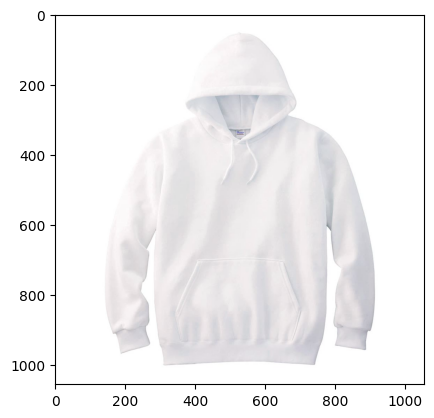

In [142]:
predict_fashion_mnist('/Users/matsumotokotarou/My_Data/Local_Programing/labo/fashion-mnist/Parker.jpg')

1/1 [==============================] - 0s 9ms/step
616


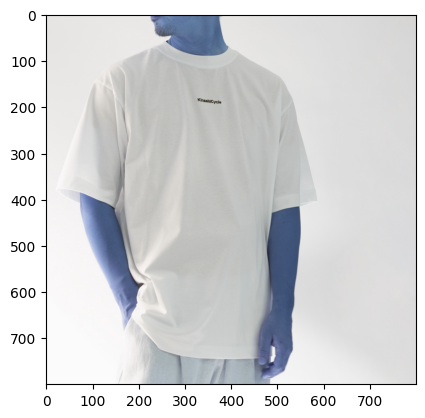

In [143]:
predict_fashion_mnist('/Users/matsumotokotarou/My_Data/Local_Programing/labo/fashion-mnist/T-shirt.jpg')